# 8. FashionCLIP Fine-grained Classification
FashionCLIP is a domain-specific fine-tuned CLIP model for fashion image-text matching. Because CLIP models are not natively detectors, we use them as classifiers on image crops.

In this notebook, we:
1. Load FashionCLIP.
2. Manually define regions of interest (or crops).
3. Classify these crops against a text corpus of fashion categories to show FashionCLIP's superior zero-shot capabilities in domain-specific tasks.



In [1]:
import os
import sys

sys.path.append(os.path.abspath("."))

from fashion_detector.config import Config
from fashion_detector.models.fashion_clip import FashionClipDetector
from fashion_detector.models.base import Detection
from fashion_detector.utils import (
    load_image,
    visualize_detections,
    user_categories,
    mapped_user_categories,
    execute_detection,
    clean_categories,
    display_imageGrid
)
from IPython.display import HTML, display

config = Config("config/config.yaml")

# Initialize FashionCLIP
classifier = FashionClipDetector(config)
classifier.load_model()

[2026-07-24 18:26:18] [INFO] [fashion_detector:config.py:169] - Configuration loaded from config/config.yaml. Device set to: mps
[2026-07-24 18:26:18] [INFO] [fashion_detector:fashion_clip.py:33] - Loading FashionCLIP model: patrickjohncyh/fashion-clip on device: mps


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


[2026-07-24 18:26:23] [INFO] [fashion_detector:fashion_clip.py:46] - FashionCLIP model loaded successfully.


## Set up manual crops (proposals)
We will take the street image and define bounding boxes for the hat, dress, and handbag, then run zero-shot classification on the crops.



In [4]:
image = load_image("data/input_images/fashion_model_street.jpg")

# Bounding box proposals (e.g. from a first-stage class-agnostic detector)
proposals = [
    Detection(box=[200.0, 300.0, 650.0, 950.0], label="unknown_clothing", score=1.0),
    Detection(box=[300.0, 100.0, 500.0, 250.0], label="unknown_accessory", score=1.0),
    Detection(box=[150.0, 650.0, 350.0, 850.0], label="unknown_handbag", score=1.0),
]

# Fashion categories we want to map them to
candidate_categories = ["dress", "skirt", "jacket", "hat", "cap", "handbag", "backpack"]

# Run Stage 2 crop classification
refined_detections = classifier.classify_crops(
    image, proposals, categories=candidate_categories
)

print("FashionCLIP Refined Categories:")
for d in refined_detections:
    print(f"Box {list(map(int, d.box))} -> Class: {d.label} (score: {d.score:.2f})")

[2026-07-24 18:26:52] [INFO] [fashion_detector:utils.py:204] - Loading image from local path: data/input_images/fashion_model_street.jpg
[2026-07-24 18:26:52] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Crop Classification
[2026-07-24 18:26:52] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-24 18:26:52] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.3441 seconds
[2026-07-24 18:26:52] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Crop Classification in 0.3978 seconds
FashionCLIP Refined Categories:
Box [200, 300, 650, 950] -> Class: skirt (score: 0.45)
Box [300, 100, 500, 250] -> Class: jacket (score: 0.86)
Box [150, 650, 350, 850] -> Class: skirt (score: 0.66)


## Visualizing refined bounding boxes


[2026-07-24 18:27:17] [INFO] [fashion_detector:utils.py:204] - Loading image from local path: data/input_images/images-2.jpeg
[2026-07-24 18:27:17] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Global Presence Extraction
[2026-07-24 18:27:17] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Crop Classification
[2026-07-24 18:27:17] [INFO] [fashion_detector:logging.py:98] - Starting: FashionCLIP Text Embeddings
[2026-07-24 18:27:17] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Text Embeddings in 0.0301 seconds
[2026-07-24 18:27:17] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Crop Classification in 0.2652 seconds
[2026-07-24 18:27:17] [INFO] [fashion_detector:logging.py:103] - Completed: FashionCLIP Global Presence Extraction in 0.2662 seconds
Verified Active Categories in Image: ['brooches', 'dresses', 'scarves', 'tops']


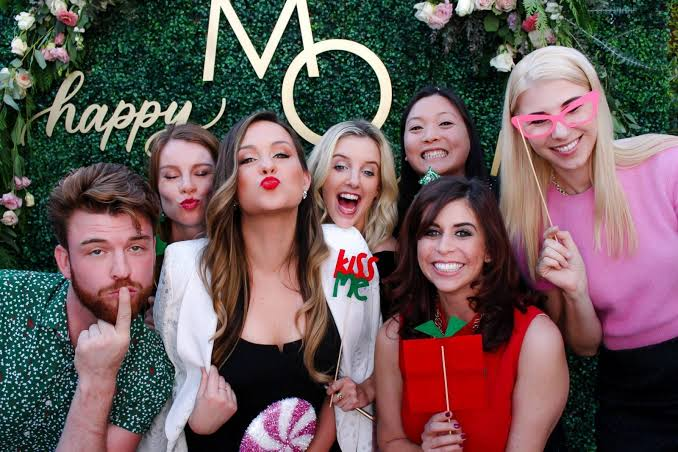

In [5]:
# Run raw visual presence verification check
image_path = "data/input_images/images-2.jpeg"
image = load_image(image_path)
active_categories = classifier.extract_present_classes(
    image=image,
    user_categories=user_categories,
    presence_threshold=0.15,  # Adjust lower to pick up minor accessories, higher to reduce loose predictions
)

print(f"Verified Active Categories in Image: {active_categories}")
display(image)  # Display the image in the notebook

In [6]:
from fashion_detector.models.grounding_dino import GroundingDinoDetector
from fashion_detector.models.florence2 import Florence2Detector

dino_detector = Florence2Detector(config)
detector = GroundingDinoDetector(config)

[2026-07-24 18:27:39] [INFO] [fashion_detector:florence2.py:44] - Florence-2 Detector initialized with model: microsoft/Florence-2-base, confidence threshold: 0.3
[2026-07-24 18:27:39] [INFO] [fashion_detector:florence2.py:47] - Florence-2 Detector default lifestyle categories: ['shirt', 't-shirt', 'polo', 'sweater', 'hoodie', 'jacket', 'blazer', 'coat', 'dress', 'top', 'jeans', 'pants', 'shorts', 'skirt', 'suit', 'jumpsuit', 'scarf', 'handbag', 'backpack', 'wallet', 'belt', 'watch', 'bracelet', 'necklace', 'earrings', 'ring', 'hat', 'cap', 'sunglasses', 'shoes', 'boots', 'sneakers']


[2026-07-24 18:27:44] [INFO] [fashion_detector:logging.py:98] - Starting: Grounding DINO Inference
[2026-07-24 18:27:44] [INFO] [fashion_detector:grounding_dino.py:33] - Loading Grounding DINO model: IDEA-Research/grounding-dino-tiny on device: mps
[2026-07-24 18:27:49] [INFO] [fashion_detector:grounding_dino.py:46] - Grounding DINO model loaded successfully.
[2026-07-24 18:27:51] [INFO] [fashion_detector:grounding_dino.py:149] - Grounding DINO detected 10 items.
[2026-07-24 18:27:51] [INFO] [fashion_detector:logging.py:103] - Completed: Grounding DINO Inference in 7.5133 seconds
Hybrid pipeline detected 10 fashion items:
- Dresses (refined from None): score=0.47
- Dresses (refined from None): score=0.41
- Dresses (refined from None): score=0.56
- Dresses (refined from None): score=0.34
- Scarves (refined from None): score=0.29
- Dresses (refined from None): score=0.28
- Scarves (refined from None): score=0.29
- Scarves (refined from None): score=0.29
- Scarves (refined from None): sco

/Users/sunnyraj/code_files/git_repos/image-segments/.venv/lib/python3.12/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:98: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)



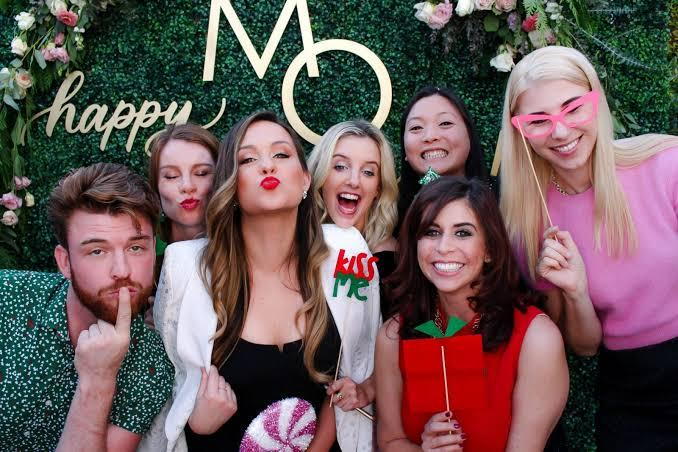

In [7]:
detections = detector.detect(image, queries=active_categories)
print(f"Hybrid pipeline detected {len(detections)} fashion items:")
for d in detections:
    print(
        f"- {d.label.capitalize()} (refined from {d.metadata.get('proposal_label')}): score={d.score:.2f}"
    )
visualize_detections(image, detector._to_dict(detections))

[2026-07-24 18:27:55] [INFO] [fashion_detector:logging.py:98] - Starting: Florence-2 Inference
[2026-07-24 18:27:55] [INFO] [fashion_detector:florence2.py:59] - Loading Florence-2 model: microsoft/Florence-2-base on device: mps


`torch_dtype` is deprecated! Use `dtype` instead!


[2026-07-24 18:28:02] [INFO] [fashion_detector:florence2.py:143] - Florence-2 model loaded successfully.
[2026-07-24 18:28:02] [INFO] [fashion_detector:florence2.py:174] - Florence-2 running task: <OD>
[2026-07-24 18:28:06] [INFO] [fashion_detector:florence2.py:282] - Florence-2 detected 3 fashion items (filtered from 18 total).
[2026-07-24 18:28:06] [INFO] [fashion_detector:logging.py:103] - Completed: Florence-2 Inference in 11.1626 seconds
Hybrid pipeline detected 3 fashion items:
- Dress (refined from None): score=1.00
- Dress (refined from None): score=1.00
- Dress (refined from None): score=1.00



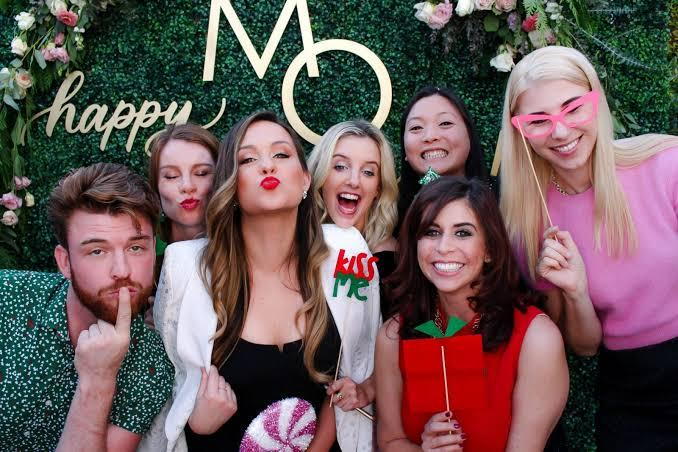

In [8]:
detections = dino_detector.detect(image, queries=active_categories)
print(f"Hybrid pipeline detected {len(detections)} fashion items:")
for d in detections:
    print(
        f"- {d.label.capitalize()} (refined from {d.metadata.get('proposal_label')}): score={d.score:.2f}"
    )
visualize_detections(image, dino_detector._to_dict(detections))